# CS 383 - Machine Learning
## Lab 6 - Support Vector Machines

### Introduction
In this lab you will implement a Support Vector Machine (SVM) for the purpose of binary classification.

You may not use any functions from an ML library in your code. And as always your code should
work on any dataset that has the same general form as the provided one.

### Grading
| Points | Description |
| ------- | --------|
|  +2pts|Can run script properly| 
|  +2pts|  Creates dataset correctly | 
|  +2pts|Creats some weights and/or alpha values| 
|  +2pts|Creates correct weights and/or alpha values| 
|  +2pts |Lose to target results| 
| ------ | ------ |
| 10pts | Total |

### Our Data
For this lab we’ll just use the same dataset I provided as an example in the recording,
namely:
$$X=\begin{bmatrix} -1 & -1\\ -1 & 1\\ 1 & -1\\ 1 & 1\end{bmatrix}, Y=\begin{bmatrix}-1\\-1\\1\\1\end{bmatrix}$$

In [92]:
#TODO
#Create your observable data matrix as X and Target matrix as Y
import numpy as np

X = np.array(   [[-1, -1],
                 [-1, 1],
                 [1, -1],
                 [1, 1,]] )
Y = np.array([[-1],[-1],[1],[1]])
print(X)
print(Y)

[[-1 -1]
 [-1  1]
 [ 1 -1]
 [ 1  1]]
[[-1]
 [-1]
 [ 1]
 [ 1]]


### Support Vector Machine
Lets design, implement and train  a *Support Vector Machine Classifier*.  For training we'll use the dataset mentioned earlier.
Perform gradient **ascent** to compute the value of $\alpha$ and the weights $w$ using the training data, keeping track of the current value of $J$ for each epoch.

For quick reference, here's the relevant formulae:
- $\frac{\partial J}{\partial \alpha} = ones(size(Y)) - diag(Y)XX^Tdiag(Y)\alpha$
- $J = \sum_{i=1}^{N}\alpha_i - \frac{1}{2}\alpha^TXX^Tdiag(Y)\alpha$
- $w=X^Tdiag(Y)\alpha$

#### Implementation Details
- Remember to z-score your data.
- Remember to add a bias feature.
- We will let you determine appropriate values for the learning rate, $\eta$ as well as an appropriate termination criteria.
- For full credit, you must run your algorithm to *convergence* (or at least until visually it pretty much flattens out).
- It is recommended that you use numpy's *diagflat* function for obtaining your diagonal matrices.

In [93]:
#TODO Create SVM model as described above
# Z-Score
mean = np.mean(X, axis=0)
stddev = np.std(X, axis=0, ddof=1)
Xz = (X - mean) / stddev

# Add Bias
Xzb = np.concatenate((Xz, np.ones((Xz.shape[0],1))),axis=1)
print(Xzb)

# Set variables
n = 0.5
MAX_EPOCHS = 100

a = np.zeros((Y.shape[0],1))
print(a)

js = []
epochs = []
# Run training algorithm
for i in range(MAX_EPOCHS):
    ones = np.ones((Y.shape[0],1))
    diagY = np.diagflat(Y)
    
    dJdalpha = ones - diagY @ Xzb @ Xzb.T @ diagY @ a
        
    J = np.sum(a) - ((1/2) * a.T @ diagY @ Xzb @ Xzb.T @ diagY @ a)    
    js.append(J[0][0])
    epochs.append(i+1)
    
    a += n * dJdalpha

    a = np.where(a < 0, 0, a)

W = Xzb.T @ diagY @ a

    


[[-0.8660254 -0.8660254  1.       ]
 [-0.8660254  0.8660254  1.       ]
 [ 0.8660254 -0.8660254  1.       ]
 [ 0.8660254  0.8660254  1.       ]]
[[0.]
 [0.]
 [0.]
 [0.]]


### Evaluation
Provide the following information
- A plot of the training process over epochs.
- Display the final values of $\alpha$ and $w$.
- Use the learned weights (and/or alpha values) to make predictions for the training data and report the system's accuracy.

Final alpha values:
[[0.33333333]
 [0.33333333]
 [0.33333333]
 [0.33333333]]
Final weights:
[[1.15470054]
 [0.        ]
 [0.        ]]
Predictions: 
[[-1]
 [-1]
 [ 1]
 [ 1]]
Accuracy: 
1.0


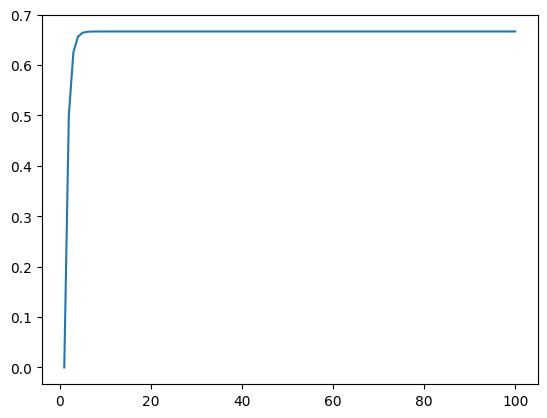

In [94]:
#TODO:  Displays information requested above.
import matplotlib.pyplot as plt

print("Final alpha values:")
print(a)

print("Final weights:")
print(w)

print("Predictions: ")
y_pred = Xzb@W
y_pred = np.where(y_pred < 0, -1, 1)
print(y_pred)

print("Accuracy: ")
print(np.mean(Y == y_pred))
x = np.array(epochs)
y = np.array(js)
plt.plot(x,y)
plt.show()